In [1]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install deepxde

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
os.environ["DDE_BACKEND"]="pytorch"

In [2]:
import deepxde as dde
import numpy as np 
import torch


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [11]:
def poisson(x,y):
    du_xx=dde.grad.hessian(y,x,i=0,j=0)
    return du_xx-2

In [12]:
geom=dde.geometry.Interval(0,1)
bc=dde.icbc.DirichletBC(geom,lambda x:0,lambda _,on_boundary:on_boundary)
data=dde.data.PDE(
    geom,
    poisson,
    [bc],
    num_domain=2000,
    num_boundary=100
)

In [13]:
net=dde.nn.FNN([1]+[32]*3+[1],"tanh","Glorot normal")
model=dde.Model(data,net)

In [14]:
model.compile("adam",lr=1e-3)
model.train(iterations=10000)
model.compile("L-BFGS")
losshistory,train_state=model.train()

Compiling model...
'compile' took 0.025739 s

Training model...

Step      Train loss              Test loss               Test metric
0         [3.75e+00, 1.05e-02]    [3.75e+00, 1.05e-02]    []  
1000      [6.32e-04, 1.47e-07]    [6.32e-04, 1.47e-07]    []  
2000      [1.56e-04, 4.51e-07]    [1.56e-04, 4.51e-07]    []  
3000      [4.21e-05, 1.42e-09]    [4.21e-05, 1.42e-09]    []  
4000      [1.41e-05, 2.04e-10]    [1.41e-05, 2.04e-10]    []  
5000      [4.97e-06, 1.05e-07]    [4.97e-06, 1.05e-07]    []  
6000      [1.87e-06, 1.03e-06]    [1.87e-06, 1.03e-06]    []  
7000      [8.58e-07, 5.07e-11]    [8.58e-07, 5.07e-11]    []  
8000      [1.15e-06, 4.99e-06]    [1.15e-06, 4.99e-06]    []  
9000      [1.72e-06, 1.28e-05]    [1.72e-06, 1.28e-05]    []  
10000     [6.59e-07, 1.14e-11]    [6.59e-07, 1.14e-11]    []  

Best model at step 10000:
  train loss: 6.59e-07
  test loss: 6.59e-07
  test metric: []

'train' took 81.270129 s

Compiling model...
'compile' took 0.007214 s

Training 

Saving loss history to d:\psd\loss.dat ...
Saving training data to d:\psd\train.dat ...
Saving test data to d:\psd\test.dat ...


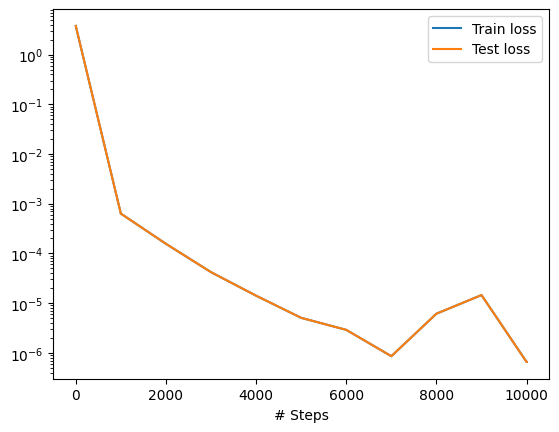

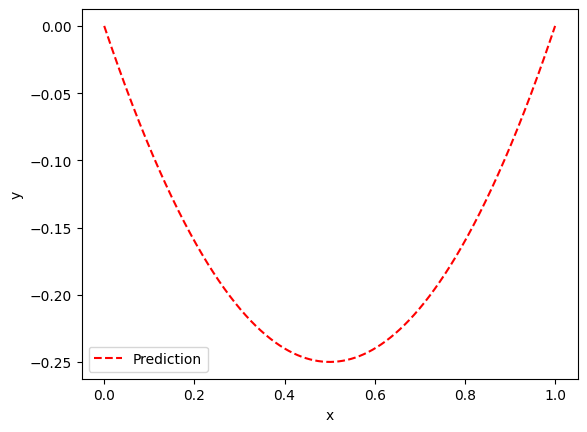

In [15]:
import matplotlib.pyplot as plt
dde.saveplot(losshistory,train_state,issave=True,isplot=True)

In [16]:
import numpy as np
point=np.array([[0.5]])
prediction=model.predict(point)
print("The predicted value is =",prediction[0][0])

The predicted value is = -0.24999721
